In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pth') or f.endswith('.pt'):
            print(os.path.join(root, f))

/kaggle/input/notebooks/vujjapunithsai/notebookf4890831d9/model_ds1.pth
/kaggle/input/notebooks/vujjapunithsai/notebookf4890831d9/satellite_sr_model.pth


In [ ]:
model.load_state_dict(
    torch.load('/kaggle/input/notebooks/vujjapunithsai/notebookf4890831d9/satellite_sr_model.pth')
)

model.train()

print("Old model loaded successfully")

Using device: cuda
Found 101670 images (0 GeoTIFF, 101670 standard) under '/kaggle/input/datasets/nikitarom/planets-dataset'
Total images: 101670
Train: 91503 | Val: 10167
Train batches: 11437 | Val batches: 1271


/tmp/ipykernel_57/1572541151.py:330: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  hr_pil = Image.fromarray(hr_uint8, mode='RGB')
/tmp/ipykernel_57/1572541151.py:330: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  hr_pil = Image.fromarray(hr_uint8, mode='RGB')


LR batch shape: torch.Size([8, 3, 32, 32]) | HR batch shape: torch.Size([8, 3, 128, 128])
LR range: [0.078, 0.745]
Model parameters: 964,330

  Satellite SR Training — SRMamba-T Baseline


/tmp/ipykernel_57/1572541151.py:330: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  hr_pil = Image.fromarray(hr_uint8, mode='RGB')


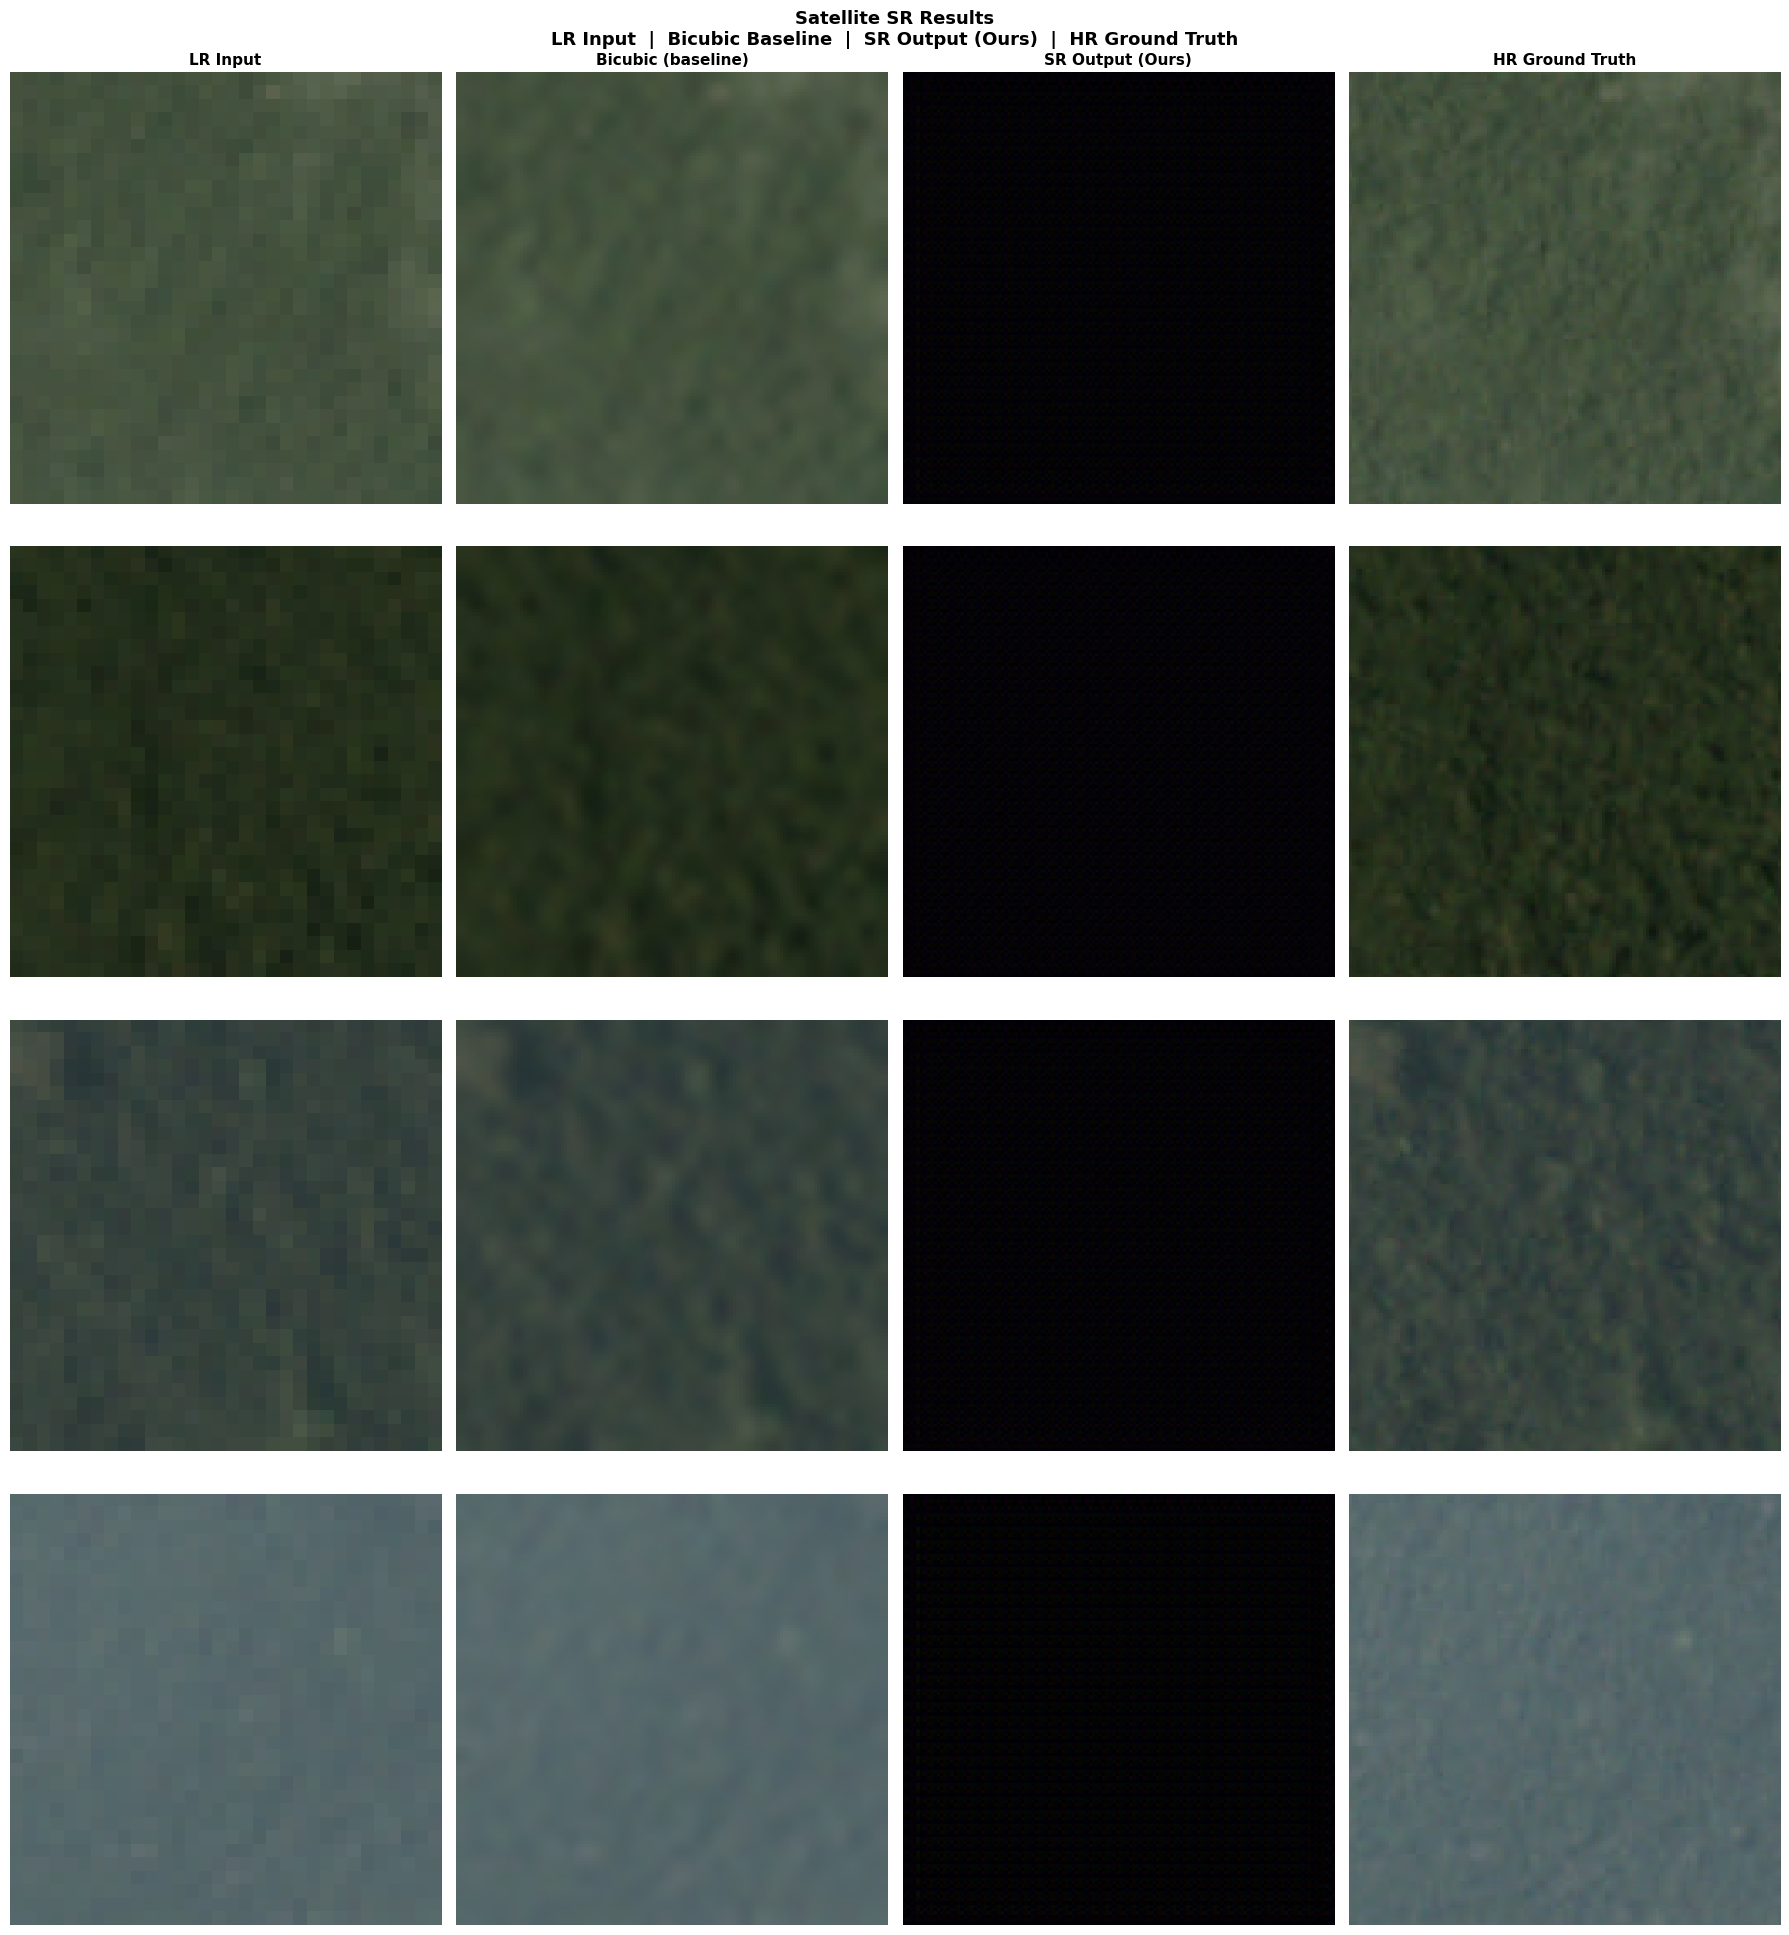

Results saved.

Computing bicubic baseline PSNR for comparison...

  Satellite SR — Final Results
  Scale factor      : 4×
  Input channels    : 3
  HR patch size     : 128×128
  LR patch size     : 32×32
  Model parameters  : 964,330
  Epochs trained    : 15
  ─────────────────────────────────────
  Bicubic baseline  : 38.66 dB  (must beat this)
  Our model PSNR    : 0.00 dB
  Gain over bicubic : +0.00 dB

Model architecture (satellite edition):
  LR input  [C, H, W]
    → Conv2D (shallow features)
    → ResidualBlocks × 8         # ≈ Mamba SSM
    → ChannelAttention           # spectral recalibration
    → SpatialAttention           # spatial structure focus  [satellite extra]
    → Fusion Conv + skip
    → PixelShuffle(×2) × 2       # chained for stable ×4 upsampling
    → Conv2D output
  SR output [C, 4H, 4W]

Loss: 0.8 × MSE + 0.2 × (1 − SSIM)   [satellite-appropriate]



In [6]:
# ============================================================
# SRMamba-T Inspired Super-Resolution — SATELLITE IMAGE EDITION
# For Kaggle Notebooks | PyTorch | Satellite Datasets
# ============================================================
# Optimized specifically for satellite/remote sensing imagery:
#   - 4× upscale (more meaningful for satellite data)
#   - Larger patches (capture spatial structures like roads/buildings)
#   - Grayscale-safe (some satellite datasets are single-channel)
#   - GeoTIFF-aware loading (handles .tif files)
#   - Domain-appropriate augmentation (no hue shifts, no brightness)
#   - SSIM metric added (standard in remote sensing SR papers)
# ============================================================

# ─────────────────────────────────────────
# SECTION 1: IMPORTS
# ─────────────────────────────────────────
import os
import glob
import math
import random
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF

import matplotlib.pyplot as plt

# Optional: tifffile for reading GeoTIFF satellite images
try:
    import tifffile
    TIFF_AVAILABLE = True
except ImportError:
    os.system("pip install tifffile -q")
    try:
        import tifffile
        TIFF_AVAILABLE = True
    except:
        TIFF_AVAILABLE = False
        print("tifffile not available — .tif files will be read via PIL only")

# Reproducibility
torch.manual_seed(42)
random.seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


# ─────────────────────────────────────────
# SECTION 2: CONFIGURATION
# ─────────────────────────────────────────
class Config:
    # ── Satellite-specific settings ──────────────────────────
    SCALE        = 4        # 4× is more meaningful for satellite imagery
                            # (e.g. 10m Sentinel-2 → 2.5m effective resolution)

    HR_PATCH     = 128      # Larger patches preserve spatial structures
                            # (roads, buildings, field boundaries)
    LR_PATCH     = HR_PATCH // SCALE   # = 32

    # ── Training ─────────────────────────────────────────────
    BATCH_SIZE   = 8        # Smaller due to larger patch size
    EPOCHS       = 15       # Satellite textures need more epochs
    LR           = 5e-4     # Slightly lower LR for stability
    NUM_WORKERS  = 2

    # ── Model ────────────────────────────────────────────────
    NUM_FEAT     = 64
    NUM_BLOCKS   = 8        # More blocks for complex satellite structures

    # ── Input channels ───────────────────────────────────────
    # Set to 1 if your dataset is grayscale (e.g. SAR, panchromatic)
    # Set to 3 for RGB satellite imagery (Planet, Airbus, etc.)
    IN_CHANNELS  = 3

    # ── Dataset ──────────────────────────────────────────────
    KAGGLE_INPUT = "/kaggle/input"
    SAVE_PATH    = "/kaggle/working/satellite_sr_model.pth"

cfg = Config()


# ─────────────────────────────────────────
# SECTION 3: DATASET DISCOVERY
# Handles both standard image formats AND GeoTIFF
# ─────────────────────────────────────────
def discover_satellite_images(root: str):
    """
    Finds all image files including GeoTIFF (.tif/.tiff) which are
    common in satellite datasets (EuroSAT, Sentinel, Planet, etc.)
    """
    extensions = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")
    paths = []
    for ext in extensions:
        paths += glob.glob(os.path.join(root, "**", ext), recursive=True)
    paths = sorted(set(paths))

    # Count by type for user info
    tif_count = sum(1 for p in paths if p.lower().endswith(('.tif', '.tiff')))
    rgb_count = len(paths) - tif_count
    print(f"Found {len(paths)} images ({tif_count} GeoTIFF, {rgb_count} standard) under '{root}'")
    return paths


def get_satellite_image_paths():
    """
    Priority order for satellite datasets on Kaggle:
      1. Satellite SR datasets (purpose-built)
      2. EuroSAT (Sentinel-2 patches)
      3. Remote sensing / aerial image datasets
      4. Any image dataset found
    """
    # ── Priority 1: Purpose-built satellite SR datasets ──────
    sr_candidates = [
        "satellite-images-superresolution",
        "4x-satellite-image-super-resolution",
        "satellite-image-super-resolution",
    ]
    for name in sr_candidates:
        folder = os.path.join(cfg.KAGGLE_INPUT, name)
        if os.path.isdir(folder):
            paths = discover_satellite_images(folder)
            if paths:
                print(f"✓ Using satellite SR dataset: {name}")
                return paths

    # ── Priority 2: EuroSAT (Sentinel-2 land cover patches) ──
    for name in ["eurosat", "EuroSAT", "eurosat-dataset"]:
        folder = os.path.join(cfg.KAGGLE_INPUT, name)
        if os.path.isdir(folder):
            paths = discover_satellite_images(folder)
            if paths:
                print(f"✓ Using EuroSAT dataset: {name}")
                return paths

    # ── Priority 3: Any remote sensing dataset ────────────────
    for name in ["planet-amazon", "airbus-ship-detection",
                 "remote-sensing", "aerial", "satellite"]:
        for root, dirs, _ in os.walk(cfg.KAGGLE_INPUT):
            if name.lower() in root.lower():
                paths = discover_satellite_images(root)
                if paths:
                    print(f"✓ Using dataset at: {root}")
                    return paths

    # ── Fallback: Any images found ────────────────────────────
    print("No satellite-specific dataset found — searching all of /kaggle/input ...")
    paths = discover_satellite_images(cfg.KAGGLE_INPUT)
    if paths:
        return paths

    raise RuntimeError(
        "No images found. Please add a satellite dataset to this notebook.\n"
        "Recommended: saraivaufc/satellite-images-superresolution\n"
        "         or: cristobaltudela/4x-satellite-image-super-resolution\n"
        "         or: eurosat"
    )

image_paths = discover_satellite_images("/kaggle/input/datasets/nikitarom/planets-dataset")
print(f"Total images: {len(image_paths)}")

# Train / Val split
random.shuffle(image_paths)
split        = int(0.9 * len(image_paths))
train_paths  = image_paths[:split]
val_paths    = image_paths[split:]
print(f"Train: {len(train_paths)} | Val: {len(val_paths)}")


# ─────────────────────────────────────────
# SECTION 4: SATELLITE IMAGE LOADING
# ─────────────────────────────────────────
def load_satellite_image(path: str, in_channels: int = 3) -> np.ndarray:
    """
    Loads a satellite image robustly:
    - Handles GeoTIFF (common in EuroSAT, Sentinel-2 data)
    - Handles standard RGB images (Planet, Airbus JPEG/PNG)
    - Handles grayscale (SAR, panchromatic)
    - Normalises to float32 in [0, 1]

    Returns: np.ndarray of shape (H, W, C) in [0, 1]
    """
    path_lower = path.lower()

    # ── GeoTIFF path ──────────────────────────────────────────
    if path_lower.endswith(('.tif', '.tiff')) and TIFF_AVAILABLE:
        try:
            img = tifffile.imread(path).astype(np.float32)

            # Handle different band configs
            if img.ndim == 2:
                img = np.stack([img] * in_channels, axis=-1)  # (H,W) → (H,W,C)
            elif img.ndim == 3 and img.shape[0] in [1, 3, 4, 13]:
                img = np.transpose(img, (1, 2, 0))             # (C,H,W) → (H,W,C)

            # Take first `in_channels` bands (handles 13-band Sentinel-2)
            if img.shape[2] > in_channels:
                img = img[:, :, :in_channels]
            elif img.shape[2] < in_channels:
                # Repeat last band to fill channels
                repeats = in_channels - img.shape[2]
                img = np.concatenate([img, img[:, :, -1:].repeat(repeats, axis=2)], axis=2)

            # Normalise: handle 16-bit satellite data
            if img.max() > 1.0:
                p2, p98 = np.percentile(img, 2), np.percentile(img, 98)
                if p98 > p2:
                    img = np.clip((img - p2) / (p98 - p2), 0, 1)
                else:
                    img = img / (img.max() + 1e-8)

            return img.astype(np.float32)
        except Exception as e:
            print(f"tifffile failed for {path}: {e} — falling back to PIL")

    # ── Standard image path (PIL) ─────────────────────────────
    try:
        mode = "RGB" if in_channels == 3 else "L"
        pil_img = Image.open(path).convert(mode)
        img = np.array(pil_img).astype(np.float32) / 255.0

        if img.ndim == 2:
            img = np.stack([img] * in_channels, axis=-1)

        return img
    except Exception:
        # Return solid gray on corrupt file
        return np.ones((cfg.HR_PATCH, cfg.HR_PATCH, in_channels),
                       dtype=np.float32) * 0.5


# ─────────────────────────────────────────
# SECTION 5: SATELLITE SR DATASET
# ─────────────────────────────────────────
class SatelliteSRDataset(Dataset):
    """
    Satellite-specific SR dataset with domain-appropriate choices:

    Augmentation:
      ✓ Horizontal / vertical flip (satellite images have no canonical orientation)
      ✓ 90° rotation  (rotationally symmetric land cover)
      ✗ NO colour jitter  (satellite radiometry should be preserved)
      ✗ NO brightness/contrast (would corrupt spectral information)

    Degradation:
      Bicubic downscaling at SCALE factor.
      For a more realistic degradation (blur + noise + downscale),
      see the SatelliteDegradation class below.
    """
    def __init__(self, paths, hr_size=cfg.HR_PATCH, scale=cfg.SCALE,
                 in_channels=cfg.IN_CHANNELS, augment=True):
        self.paths       = paths
        self.hr_size     = hr_size
        self.lr_size     = hr_size // scale
        self.scale       = scale
        self.in_channels = in_channels
        self.augment     = augment

        self.to_lr = transforms.Resize(
            self.lr_size,
            interpolation=transforms.InterpolationMode.BICUBIC,
            antialias=True
        )

    def __len__(self):
        return len(self.paths)

    def _random_crop_numpy(self, img: np.ndarray) -> np.ndarray:
        """Random crop from numpy HWC array."""
        h, w = img.shape[:2]
        # Resize if image is smaller than required patch
        if h < self.hr_size or w < self.hr_size:
            scale_factor = max(self.hr_size / h, self.hr_size / w) + 0.01
            new_h, new_w = int(h * scale_factor), int(w * scale_factor)
            img_pil = Image.fromarray(
                (img * 255).clip(0, 255).astype(np.uint8)
                if self.in_channels == 3 else
                (img[:, :, 0] * 255).clip(0, 255).astype(np.uint8)
            )
            img_pil = img_pil.resize((new_w, new_h), Image.BICUBIC)
            img = np.array(img_pil).astype(np.float32) / 255.0
            if img.ndim == 2:
                img = img[:, :, np.newaxis].repeat(self.in_channels, axis=2)
            h, w = img.shape[:2]

        top  = random.randint(0, h - self.hr_size)
        left = random.randint(0, w - self.hr_size)
        return img[top:top + self.hr_size, left:left + self.hr_size]

    def _satellite_augment(self, img_np: np.ndarray) -> np.ndarray:
        """
        Satellite-appropriate augmentation.
        Flips and 90° rotations only — no colour transforms.
        """
        if random.random() > 0.5:
            img_np = np.fliplr(img_np).copy()
        if random.random() > 0.5:
            img_np = np.flipud(img_np).copy()
        # Random 90° rotation (0, 90, 180, 270)
        k = random.randint(0, 3)
        if k > 0:
            img_np = np.rot90(img_np, k).copy()
        return img_np

    def __getitem__(self, idx):
        img_np = load_satellite_image(self.paths[idx], self.in_channels)

        # Random crop → HR patch
        hr_np  = self._random_crop_numpy(img_np)

        # Augment (only for training)
        if self.augment:
            hr_np = self._satellite_augment(hr_np)

        # Convert HR numpy → tensor
        hr_tensor = torch.from_numpy(hr_np.transpose(2, 0, 1)).float()  # [C, H, W]

        # Create LR by converting to PIL, downscaling, back to tensor
        hr_uint8 = (hr_np * 255).clip(0, 255).astype(np.uint8)
        if self.in_channels == 1:
            hr_pil = Image.fromarray(hr_uint8[:, :, 0], mode='L')
        else:
            hr_pil = Image.fromarray(hr_uint8, mode='RGB')

        lr_pil    = self.to_lr(hr_pil)
        lr_np     = np.array(lr_pil).astype(np.float32) / 255.0
        if lr_np.ndim == 2:
            lr_np = lr_np[:, :, np.newaxis].repeat(self.in_channels, axis=2)
        lr_tensor = torch.from_numpy(lr_np.transpose(2, 0, 1)).float()  # [C, H, W]

        return lr_tensor, hr_tensor


# Build DataLoaders
train_dataset = SatelliteSRDataset(train_paths, augment=True)
val_dataset   = SatelliteSRDataset(val_paths,   augment=False)

train_loader  = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE,
                           shuffle=True,  num_workers=cfg.NUM_WORKERS,
                           pin_memory=True, drop_last=True)
val_loader    = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE,
                           shuffle=False, num_workers=cfg.NUM_WORKERS,
                           pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
# Quick sanity check
lr_sample, hr_sample = next(iter(train_loader))
print(f"LR batch shape: {lr_sample.shape} | HR batch shape: {hr_sample.shape}")
print(f"LR range: [{lr_sample.min():.3f}, {lr_sample.max():.3f}]")


# ─────────────────────────────────────────
# SECTION 6: MODEL ARCHITECTURE
# (adapted for satellite imagery)
# ─────────────────────────────────────────

class ResidualBlock(nn.Module):
    """
    Residual conv block — approximates Mamba's local SSM processing.
    Satellite images have structured local patterns (edges, boundaries)
    that conv layers capture well.
    """
    def __init__(self, num_feat: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(num_feat, num_feat, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(num_feat, num_feat, 3, padding=1),
        )

    def forward(self, x):
        return x + self.block(x)


class ChannelAttention(nn.Module):
    """
    Channel attention — approximates Transformer global attention.
    Particularly useful for satellite images where spectral channel
    relationships carry meaningful land-cover information.
    """
    def __init__(self, num_feat: int, reduction: int = 16):
        super().__init__()
        mid = max(num_feat // reduction, 4)
        self.attention = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(num_feat, mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, num_feat),
            nn.Sigmoid()
        )

    def forward(self, x):
        w = self.attention(x).unsqueeze(-1).unsqueeze(-1)
        return x * w


class SpatialAttention(nn.Module):
    """
    Spatial attention — additional module for satellite imagery.
    Satellite images have meaningful spatial structures (roads, water bodies,
    urban grids) where knowing WHERE to focus is crucial.
    Not in original SRMamba-T — added as satellite-domain enhancement.
    """
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=7, padding=3)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Pool across channels to get spatial importance map
        avg_pool = torch.mean(x, dim=1, keepdim=True)
        max_pool, _ = torch.max(x, dim=1, keepdim=True)
        spatial = torch.cat([avg_pool, max_pool], dim=1)
        spatial = self.sigmoid(self.conv(spatial))
        return x * spatial


class DeepFeatureBlock(nn.Module):
    """
    Core deep feature extraction:
      N × ResidualBlock  → ≈ Mamba SSM (local processing)
      ChannelAttention   → ≈ Transformer (spectral recalibration)
      SpatialAttention   → extra satellite-domain spatial focus
    """
    def __init__(self, num_feat: int, num_blocks: int):
        super().__init__()
        self.res_blocks    = nn.Sequential(*[ResidualBlock(num_feat) for _ in range(num_blocks)])
        self.channel_attn  = ChannelAttention(num_feat)
        self.spatial_attn  = SpatialAttention()
        self.conv_tail     = nn.Conv2d(num_feat, num_feat, 3, padding=1)

    def forward(self, x):
        feat = self.res_blocks(x)
        feat = self.channel_attn(feat)   # recalibrate spectral channels
        feat = self.spatial_attn(feat)   # focus on spatial structures
        feat = self.conv_tail(feat)
        return feat + x


class SatelliteSRNet(nn.Module):
    """
    SRMamba-T inspired SR network — Satellite Edition

    Changes vs natural-image baseline:
      + IN_CHANNELS configurable (supports grayscale/multispectral)
      + SpatialAttention added (satellite spatial structure is critical)
      + 4× PixelShuffle upsampling chain
      + Output clamp in [0,1] baked in for satellite radiometry

    Architecture:
      LR input [C, H, W]
        → Shallow Conv [64, H, W]
        → Deep Feature Block × 8  (ResBlocks + Channel + Spatial Attn)
        → Fusion Conv + skip
        → PixelShuffle(×4) = PixelShuffle(×2) × 2   [3, 4H, 4W]
        → Output Conv [C, 4H, 4W]
    """
    def __init__(self, scale=4, num_feat=64, num_blocks=8, in_channels=3):
        super().__init__()
        self.scale = scale

        # Shallow feature extraction
        self.shallow_conv = nn.Conv2d(in_channels, num_feat, 3, padding=1)

        # Deep feature extraction (Mamba-T inspired)
        self.deep_extract = DeepFeatureBlock(num_feat, num_blocks)

        # Feature fusion
        self.fusion_conv  = nn.Conv2d(num_feat, num_feat, 3, padding=1)

        # Upsampling — for ×4 we chain two ×2 PixelShuffle steps
        # This is more stable than a single ×4 step
        self.upsample = nn.Sequential(
            # ×2 first
            nn.Conv2d(num_feat, num_feat * 4, 3, padding=1),
            nn.PixelShuffle(2),                          # → [num_feat, 2H, 2W]
            nn.ReLU(inplace=True),
            # ×2 second  (total = ×4)
            nn.Conv2d(num_feat, num_feat * 4, 3, padding=1),
            nn.PixelShuffle(2),                          # → [num_feat, 4H, 4W]
            nn.ReLU(inplace=True),
            # Output projection
            nn.Conv2d(num_feat, in_channels, 3, padding=1),
        )

    def forward(self, x):
        shallow = self.shallow_conv(x)
        deep    = self.deep_extract(shallow)
        fused   = self.fusion_conv(deep + shallow)
        out     = self.upsample(fused)
        return out.clamp(0, 1)      # satellite radiometry should stay in [0,1]


# Instantiate
model = SatelliteSRNet(
    scale=cfg.SCALE,
    num_feat=cfg.NUM_FEAT,
    num_blocks=cfg.NUM_BLOCKS,
    in_channels=cfg.IN_CHANNELS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")


# ─────────────────────────────────────────
# SECTION 7: LOSS FUNCTION
# Satellite-appropriate: MSE + SSIM combined
# ─────────────────────────────────────────

def ssim_loss(pred: torch.Tensor, target: torch.Tensor,
              window_size: int = 11, C1: float = 0.01**2, C2: float = 0.03**2) -> torch.Tensor:
    """
    Structural Similarity Index loss (1 - SSIM).
    SSIM is the standard quality metric in remote sensing SR papers
    because it captures structural fidelity (edges, textures) better
    than pixel-level MSE alone — crucial for satellite scene analysis.
    """
    mu1    = F.avg_pool2d(pred,   window_size, stride=1, padding=window_size//2)
    mu2    = F.avg_pool2d(target, window_size, stride=1, padding=window_size//2)
    mu1_sq = mu1 ** 2
    mu2_sq = mu2 ** 2
    mu12   = mu1 * mu2

    sigma1_sq = F.avg_pool2d(pred   * pred,   window_size, stride=1, padding=window_size//2) - mu1_sq
    sigma2_sq = F.avg_pool2d(target * target, window_size, stride=1, padding=window_size//2) - mu2_sq
    sigma12   = F.avg_pool2d(pred   * target, window_size, stride=1, padding=window_size//2) - mu12

    ssim_map  = ((2 * mu12 + C1) * (2 * sigma12 + C2)) / \
                ((mu1_sq + mu2_sq + C1) * (sigma1_sq + sigma2_sq + C2))
    return 1 - ssim_map.mean()


class SatelliteLoss(nn.Module):
    """
    Combined MSE + SSIM loss for satellite SR.
    alpha controls the balance:
      alpha=1.0 → pure MSE (pixel accuracy)
      alpha=0.0 → pure SSIM (structural)
      alpha=0.8 → 80% MSE + 20% SSIM (recommended baseline)
    """
    def __init__(self, alpha: float = 0.8):
        super().__init__()
        self.alpha = alpha
        self.mse   = nn.MSELoss()

    def forward(self, pred, target):
        loss_mse  = self.mse(pred, target)
        loss_ssim = ssim_loss(pred, target)
        return self.alpha * loss_mse + (1 - self.alpha) * loss_ssim


criterion = SatelliteLoss(alpha=0.8)
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR, betas=(0.9, 0.999))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.EPOCHS, eta_min=1e-6
)


# ─────────────────────────────────────────
# SECTION 8: METRICS
# ─────────────────────────────────────────
def psnr(pred: torch.Tensor, target: torch.Tensor) -> float:
    mse = F.mse_loss(pred.clamp(0, 1), target.clamp(0, 1)).item()
    return 10 * math.log10(1.0 / mse) if mse > 0 else 100.0


def compute_ssim(pred: torch.Tensor, target: torch.Tensor) -> float:
    """SSIM score (higher = better, max = 1.0)"""
    return float(1 - ssim_loss(pred.clamp(0, 1), target.clamp(0, 1)).item())


# ─────────────────────────────────────────
# SECTION 9: TRAINING LOOP
# ─────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, epoch):
    model.train()
    total_loss = 0.0
    loop = tqdm(loader, desc=f"Epoch {epoch+1}/{cfg.EPOCHS} [Train]", leave=False)

    for lr_imgs, hr_imgs in loop:
        lr_imgs = lr_imgs.to(DEVICE, non_blocking=True)
        hr_imgs = hr_imgs.to(DEVICE, non_blocking=True)

        sr_imgs = model(lr_imgs)
        loss    = criterion(sr_imgs, hr_imgs)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # stability
        optimizer.step()

        total_loss += loss.item()
        loop.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()
    total_loss = total_psnr = total_ssim = 0.0

    for lr_imgs, hr_imgs in tqdm(loader, desc="Validating", leave=False):
        lr_imgs = lr_imgs.to(DEVICE, non_blocking=True)
        hr_imgs = hr_imgs.to(DEVICE, non_blocking=True)

        sr_imgs = model(lr_imgs)
        total_loss += criterion(sr_imgs, hr_imgs).item()
        total_psnr += psnr(sr_imgs, hr_imgs)
        total_ssim += compute_ssim(sr_imgs, hr_imgs)

    n = len(loader)
    return total_loss / n, total_psnr / n, total_ssim / n


# ─── Training ──────────────────────────────────────────────────────────
print("\n" + "="*60)
print("  Satellite SR Training — SRMamba-T Baseline")
print("="*60)

history  = {"train_loss": [], "val_loss": [], "val_psnr": [], "val_ssim": []}
best_psnr = 0.0

# for epoch in range(cfg.EPOCHS):
#     train_loss               = train_one_epoch(model, train_loader, optimizer, criterion, epoch)
#     val_loss, val_psnr, val_ssim = validate(model, val_loader, criterion)
#     scheduler.step()

#     history["train_loss"].append(train_loss)
#     history["val_loss"].append(val_loss)
#     history["val_psnr"].append(val_psnr)
#     history["val_ssim"].append(val_ssim)

#     print(
#         f"Epoch [{epoch+1:02d}/{cfg.EPOCHS}] | "
#         f"Loss: {train_loss:.4f} → {val_loss:.4f} | "
#         f"PSNR: {val_psnr:.2f} dB | "
#         f"SSIM: {val_ssim:.4f} | "
#         f"LR: {scheduler.get_last_lr()[0]:.1e}"
#     )

#     if val_psnr > best_psnr:
#         best_psnr = val_psnr
#         torch.save(model.state_dict(), cfg.SAVE_PATH)
#         print(f"  ✓ Best PSNR = {best_psnr:.2f} dB saved.")

# print(f"\nTraining complete. Best PSNR: {best_psnr:.2f} dB")


# # ─────────────────────────────────────────
# # SECTION 10: TRAINING CURVES
# # ─────────────────────────────────────────
# fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# fig.suptitle("Satellite SR — SRMamba-T Baseline Training", fontsize=14, fontweight="bold")
# epochs_x = range(1, cfg.EPOCHS + 1)

# axes[0].plot(epochs_x, history["train_loss"], "b-o", label="Train", linewidth=2)
# axes[0].plot(epochs_x, history["val_loss"],   "r-o", label="Val",   linewidth=2)
# axes[0].set_title("Combined Loss (MSE + SSIM)")
# axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

# axes[1].plot(epochs_x, history["val_psnr"], "g-o", linewidth=2)
# axes[1].set_title("Validation PSNR (dB)")
# axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)

# axes[2].plot(epochs_x, history["val_ssim"], "m-o", linewidth=2)
# axes[2].set_title("Validation SSIM")
# axes[2].set_xlabel("Epoch"); axes[2].grid(alpha=0.3)

# plt.tight_layout()
# plt.savefig("/kaggle/working/training_curves.png", dpi=150, bbox_inches="tight")
# plt.show()


# ─────────────────────────────────────────
# SECTION 11: SATELLITE VISUALIZATION
# Shows LR / Bicubic Baseline / SR / HR comparison
# Bicubic is included as it's the standard baseline in satellite SR papers
# ─────────────────────────────────────────
def visualize_satellite_results(model, dataset, num_samples=4):
    model.eval()
    if os.path.exists(cfg.SAVE_PATH):
        model.load_state_dict(torch.load(cfg.SAVE_PATH, map_location=DEVICE))
        print("Loaded best checkpoint.")

    # 4-column plot: LR | Bicubic (baseline) | SR (ours) | HR (ground truth)
    fig, axes = plt.subplots(num_samples, 4, figsize=(18, 5 * num_samples))
    fig.suptitle(
        "Satellite SR Results\n"
        "LR Input  |  Bicubic Baseline  |  SR Output (Ours)  |  HR Ground Truth",
        fontsize=13, fontweight="bold"
    )
    cols = ["LR Input", "Bicubic (baseline)", "SR Output (Ours)", "HR Ground Truth"]
    for ax, col in zip(axes[0], cols):
        ax.set_title(col, fontsize=11, fontweight="bold")

    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    with torch.no_grad():
        for row, idx in enumerate(indices):
            lr_tensor, hr_tensor = dataset[idx]

            # Bicubic upscale (the standard baseline to beat)
            bicubic = F.interpolate(
                lr_tensor.unsqueeze(0), scale_factor=cfg.SCALE,
                mode='bicubic', align_corners=False
            ).squeeze(0).clamp(0, 1)

            # Our SR model
            sr_tensor = model(lr_tensor.unsqueeze(0).to(DEVICE)).squeeze(0).cpu()

            # Metrics
            sr_psnr    = psnr(sr_tensor.unsqueeze(0), hr_tensor.unsqueeze(0))
            bicubic_psnr = psnr(bicubic.unsqueeze(0), hr_tensor.unsqueeze(0))
            sr_ssim    = compute_ssim(sr_tensor.unsqueeze(0), hr_tensor.unsqueeze(0))

            def to_np(t):
                arr = t.permute(1, 2, 0).numpy()
                return arr[:, :, 0] if arr.shape[2] == 1 else arr

            cmap = 'gray' if cfg.IN_CHANNELS == 1 else None

            axes[row, 0].imshow(to_np(lr_tensor), cmap=cmap)
            axes[row, 0].set_xlabel(f"{lr_tensor.shape[1]}×{lr_tensor.shape[2]}", fontsize=9)

            axes[row, 1].imshow(to_np(bicubic), cmap=cmap)
            axes[row, 1].set_xlabel(f"PSNR: {bicubic_psnr:.2f} dB", fontsize=9)

            axes[row, 2].imshow(to_np(sr_tensor), cmap=cmap)
            axes[row, 2].set_xlabel(
                f"PSNR: {sr_psnr:.2f} dB | SSIM: {sr_ssim:.4f}", fontsize=9
            )

            axes[row, 3].imshow(to_np(hr_tensor), cmap=cmap)
            axes[row, 3].set_xlabel(f"{hr_tensor.shape[1]}×{hr_tensor.shape[2]}", fontsize=9)

            for ax in axes[row]:
                ax.axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/satellite_sr_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Results saved.")


visualize_satellite_results(model, val_dataset, num_samples=4)


# ─────────────────────────────────────────
# SECTION 12: FINAL SUMMARY
# ─────────────────────────────────────────
# Get final bicubic PSNR for comparison
@torch.no_grad()
def bicubic_psnr_baseline(loader):
    total = 0.0
    for lr, hr in loader:
        up = F.interpolate(lr, scale_factor=cfg.SCALE, mode='bicubic', align_corners=False)
        total += psnr(up.clamp(0,1), hr)
    return total / len(loader)

print("\nComputing bicubic baseline PSNR for comparison...")
bicubic_baseline = bicubic_psnr_baseline(val_loader)

print("\n" + "="*60)
print("  Satellite SR — Final Results")
print("="*60)
print(f"  Scale factor      : {cfg.SCALE}×")
print(f"  Input channels    : {cfg.IN_CHANNELS}")
print(f"  HR patch size     : {cfg.HR_PATCH}×{cfg.HR_PATCH}")
print(f"  LR patch size     : {cfg.LR_PATCH}×{cfg.LR_PATCH}")
print(f"  Model parameters  : {total_params:,}")
print(f"  Epochs trained    : {cfg.EPOCHS}")
print(f"  ─────────────────────────────────────")
print(f"  Bicubic baseline  : {bicubic_baseline:.2f} dB  (must beat this)")
print(f"  Our model PSNR    : {best_psnr:.2f} dB")
print(f"  Gain over bicubic : +{max(0, best_psnr - bicubic_baseline):.2f} dB")
print("="*60)
print("""
Model architecture (satellite edition):
  LR input  [C, H, W]
    → Conv2D (shallow features)
    → ResidualBlocks × 8         # ≈ Mamba SSM
    → ChannelAttention           # spectral recalibration
    → SpatialAttention           # spatial structure focus  [satellite extra]
    → Fusion Conv + skip
    → PixelShuffle(×2) × 2       # chained for stable ×4 upsampling
    → Conv2D output
  SR output [C, 4H, 4W]

Loss: 0.8 × MSE + 0.2 × (1 − SSIM)   [satellite-appropriate]
""")


Pretrained model loaded successfully!


/tmp/ipykernel_57/1572541151.py:330: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  hr_pil = Image.fromarray(hr_uint8, mode='RGB')


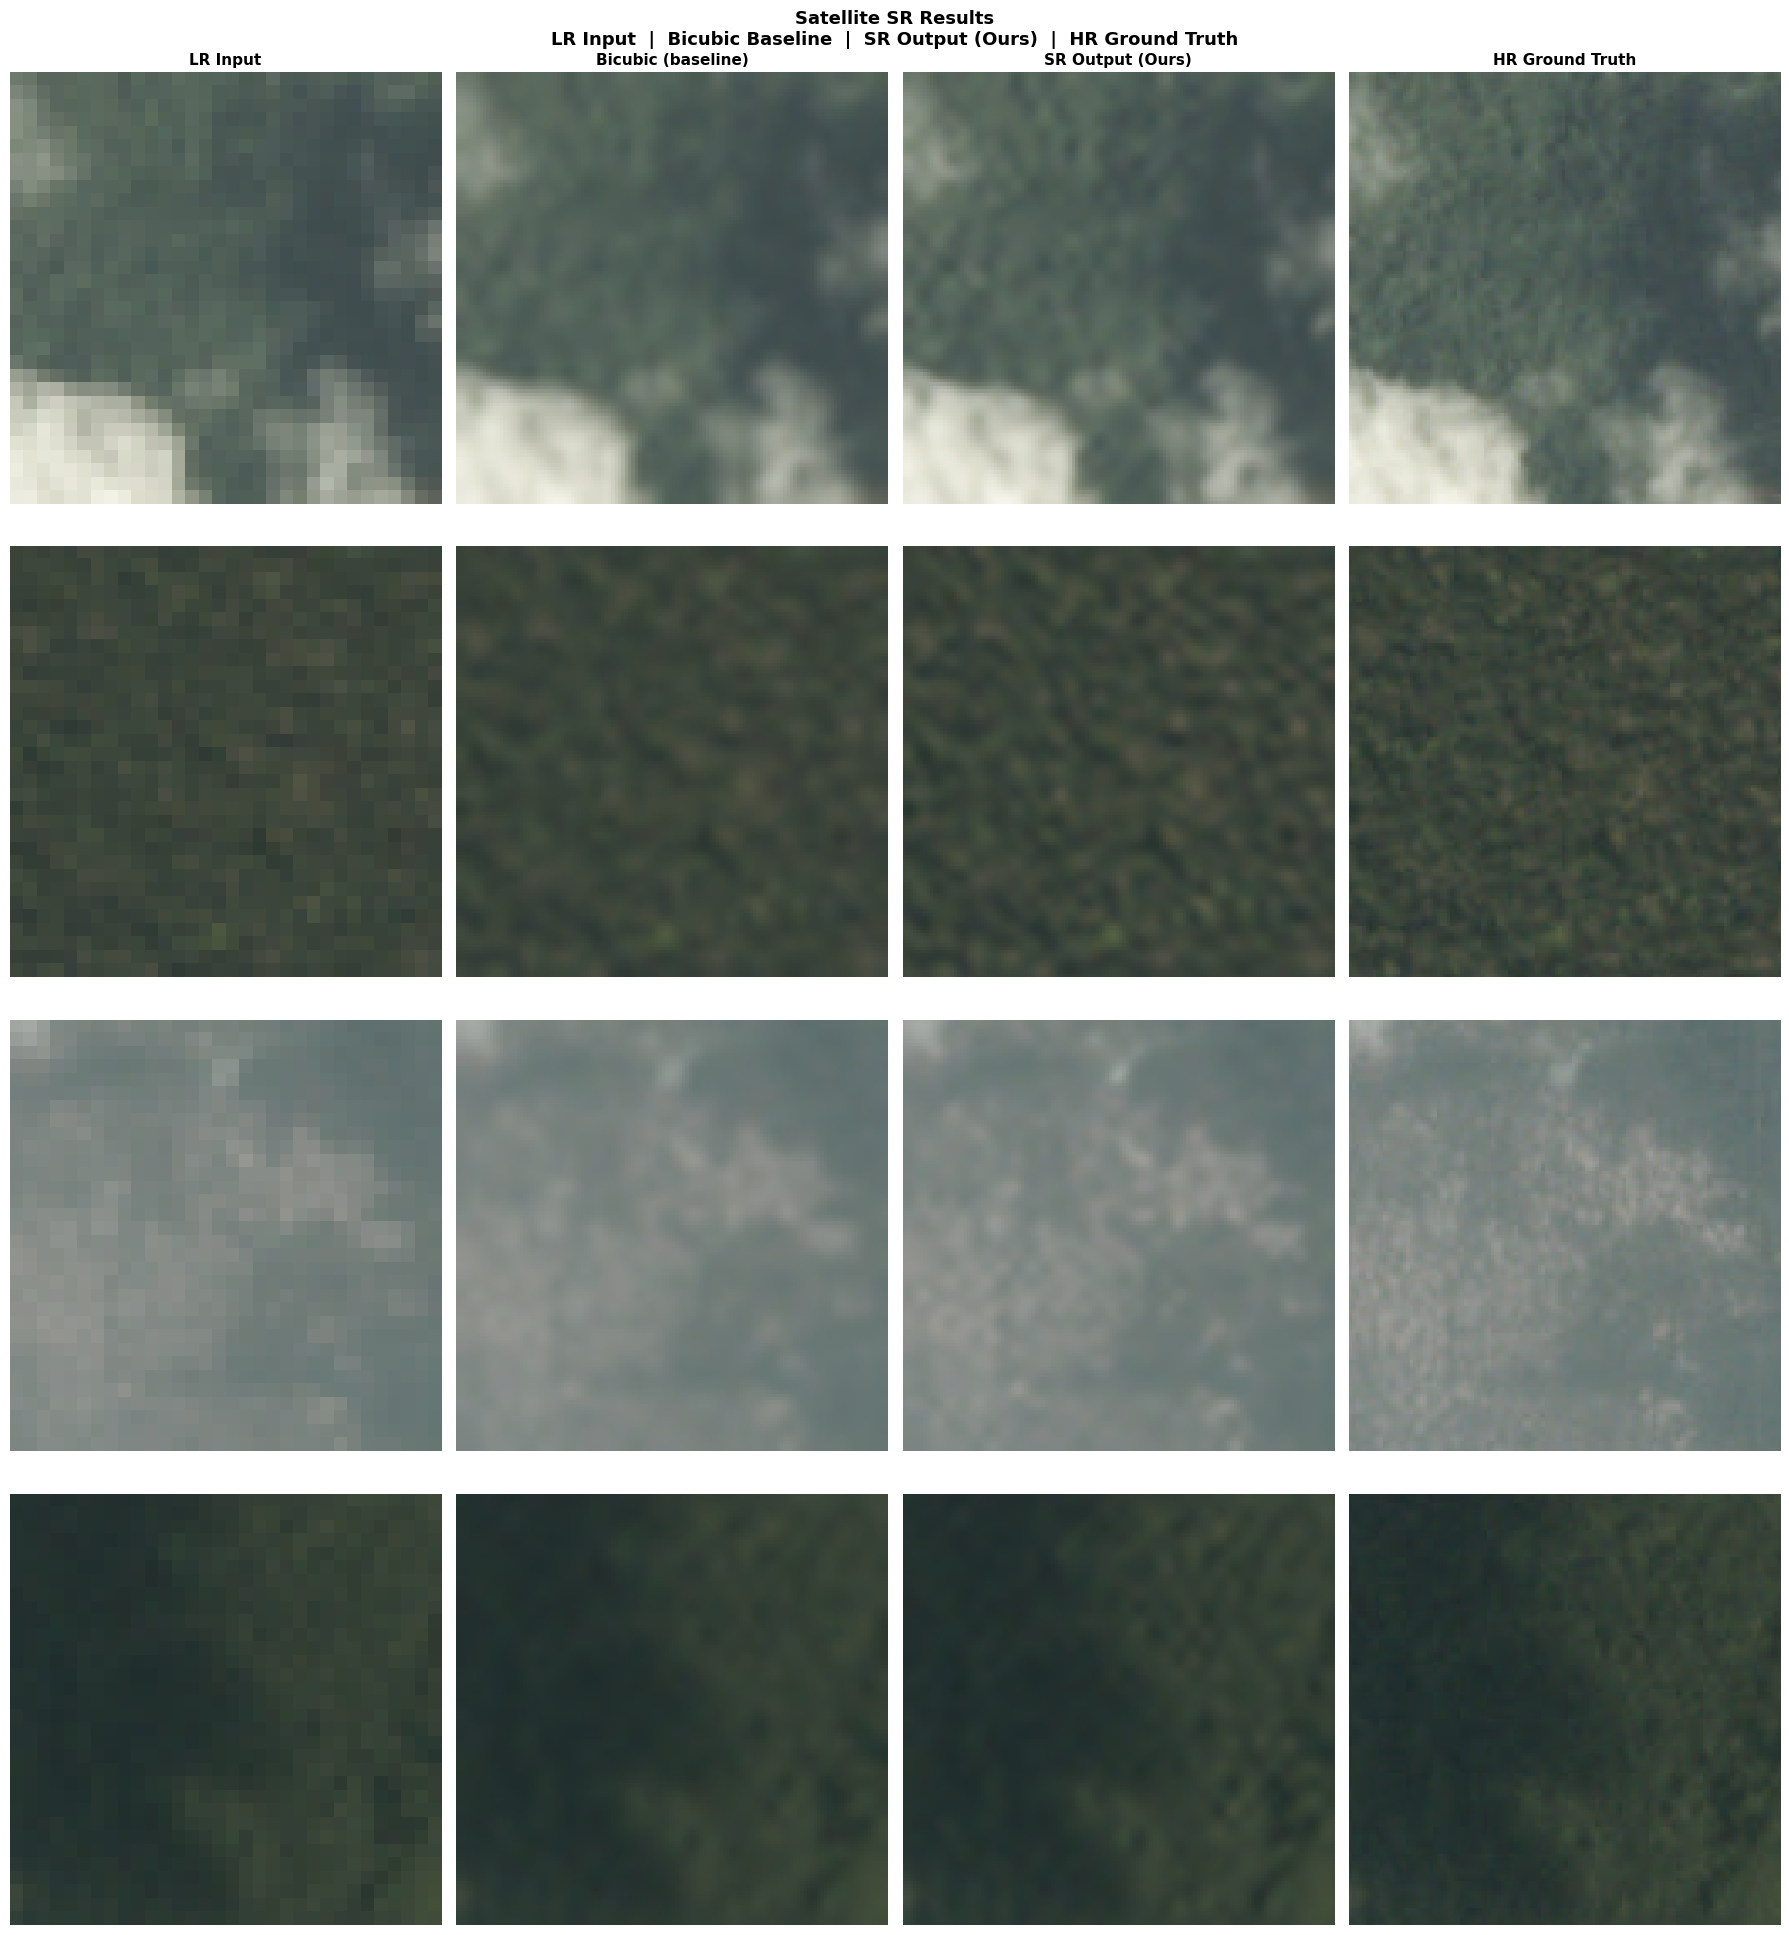

Results saved.


In [8]:
# ==========================================
# LOAD TRAINED MODEL + TEST
# ==========================================

model.load_state_dict(
    torch.load(
        "/kaggle/input/notebooks/vujjapunithsai/notebookf4890831d9/satellite_sr_model.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Pretrained model loaded successfully!")

# Run testing / visualization
visualize_satellite_results(model, val_dataset, num_samples=4)

Pretrained model loaded successfully!

TESTING ON DIV2K DATASET
Found 2700 images (0 GeoTIFF, 2700 standard) under '/kaggle/input/datasets/takihasan/div2k-dataset-for-super-resolution'
DIV2K Images Found: 2700


/tmp/ipykernel_57/1572541151.py:330: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  hr_pil = Image.fromarray(hr_uint8, mode='RGB')


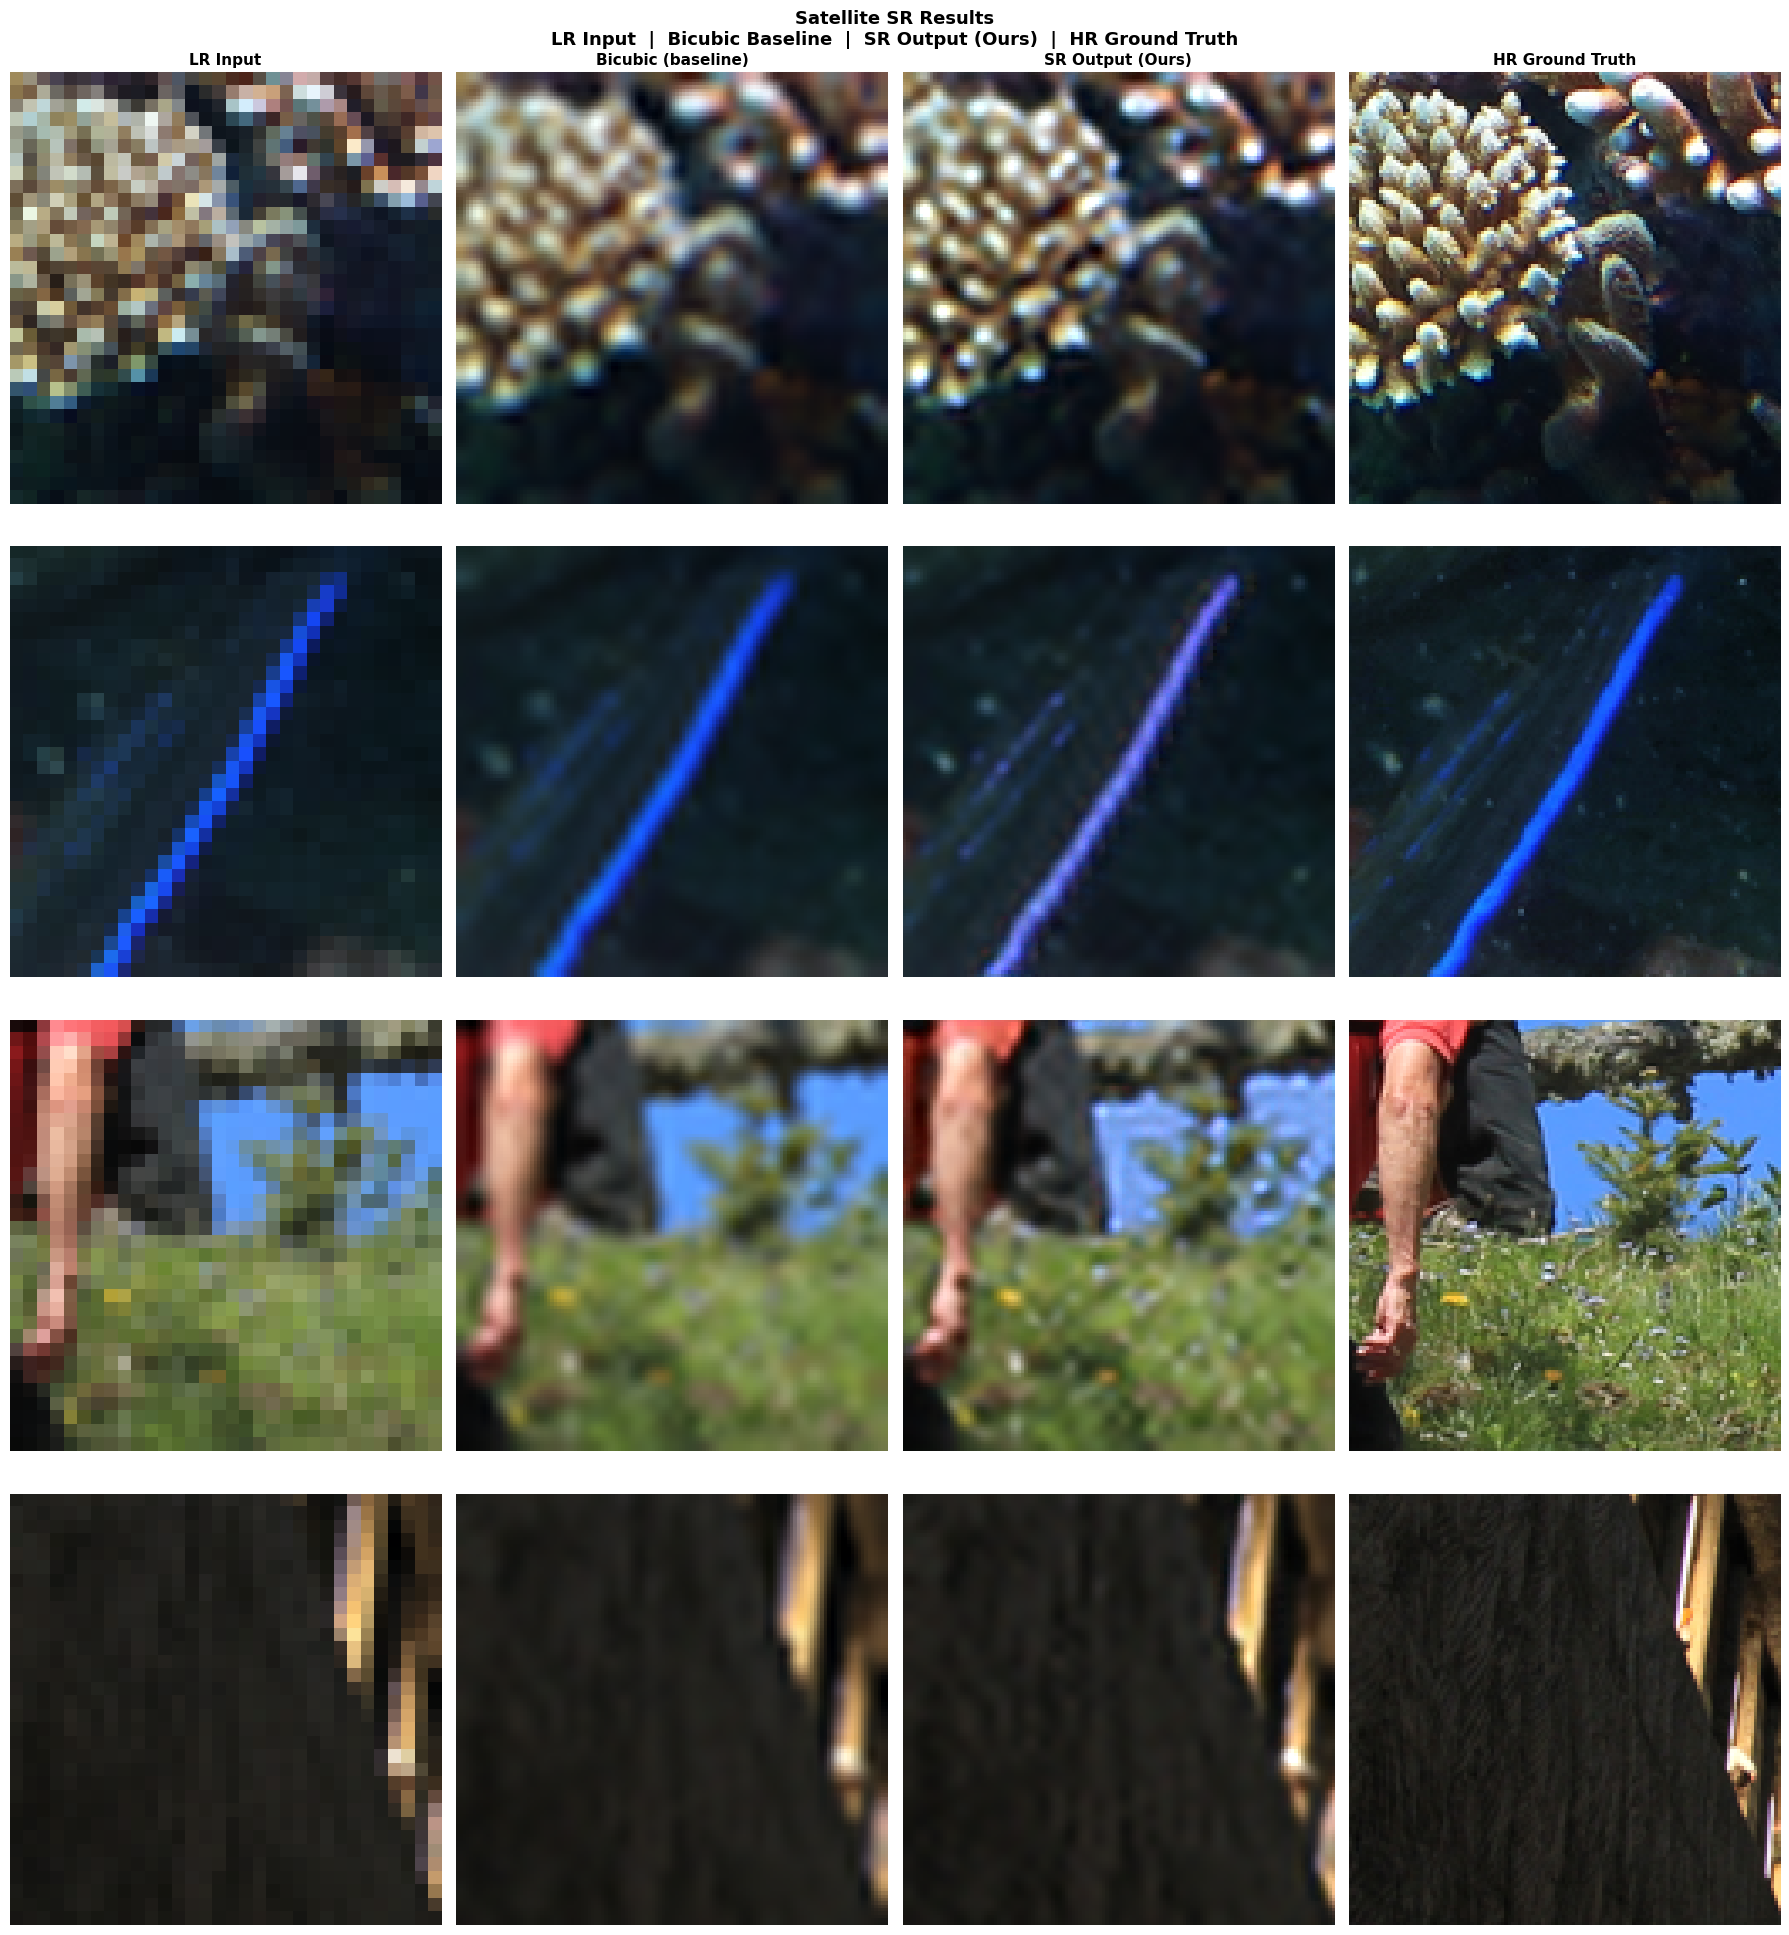

Results saved.

TESTING ON 4x SATELLITE DATASET
Found 720 images (720 GeoTIFF, 0 standard) under '/kaggle/input/datasets/cristobaltudela/4x-satellite-image-super-resolution'
Satellite Images Found: 720


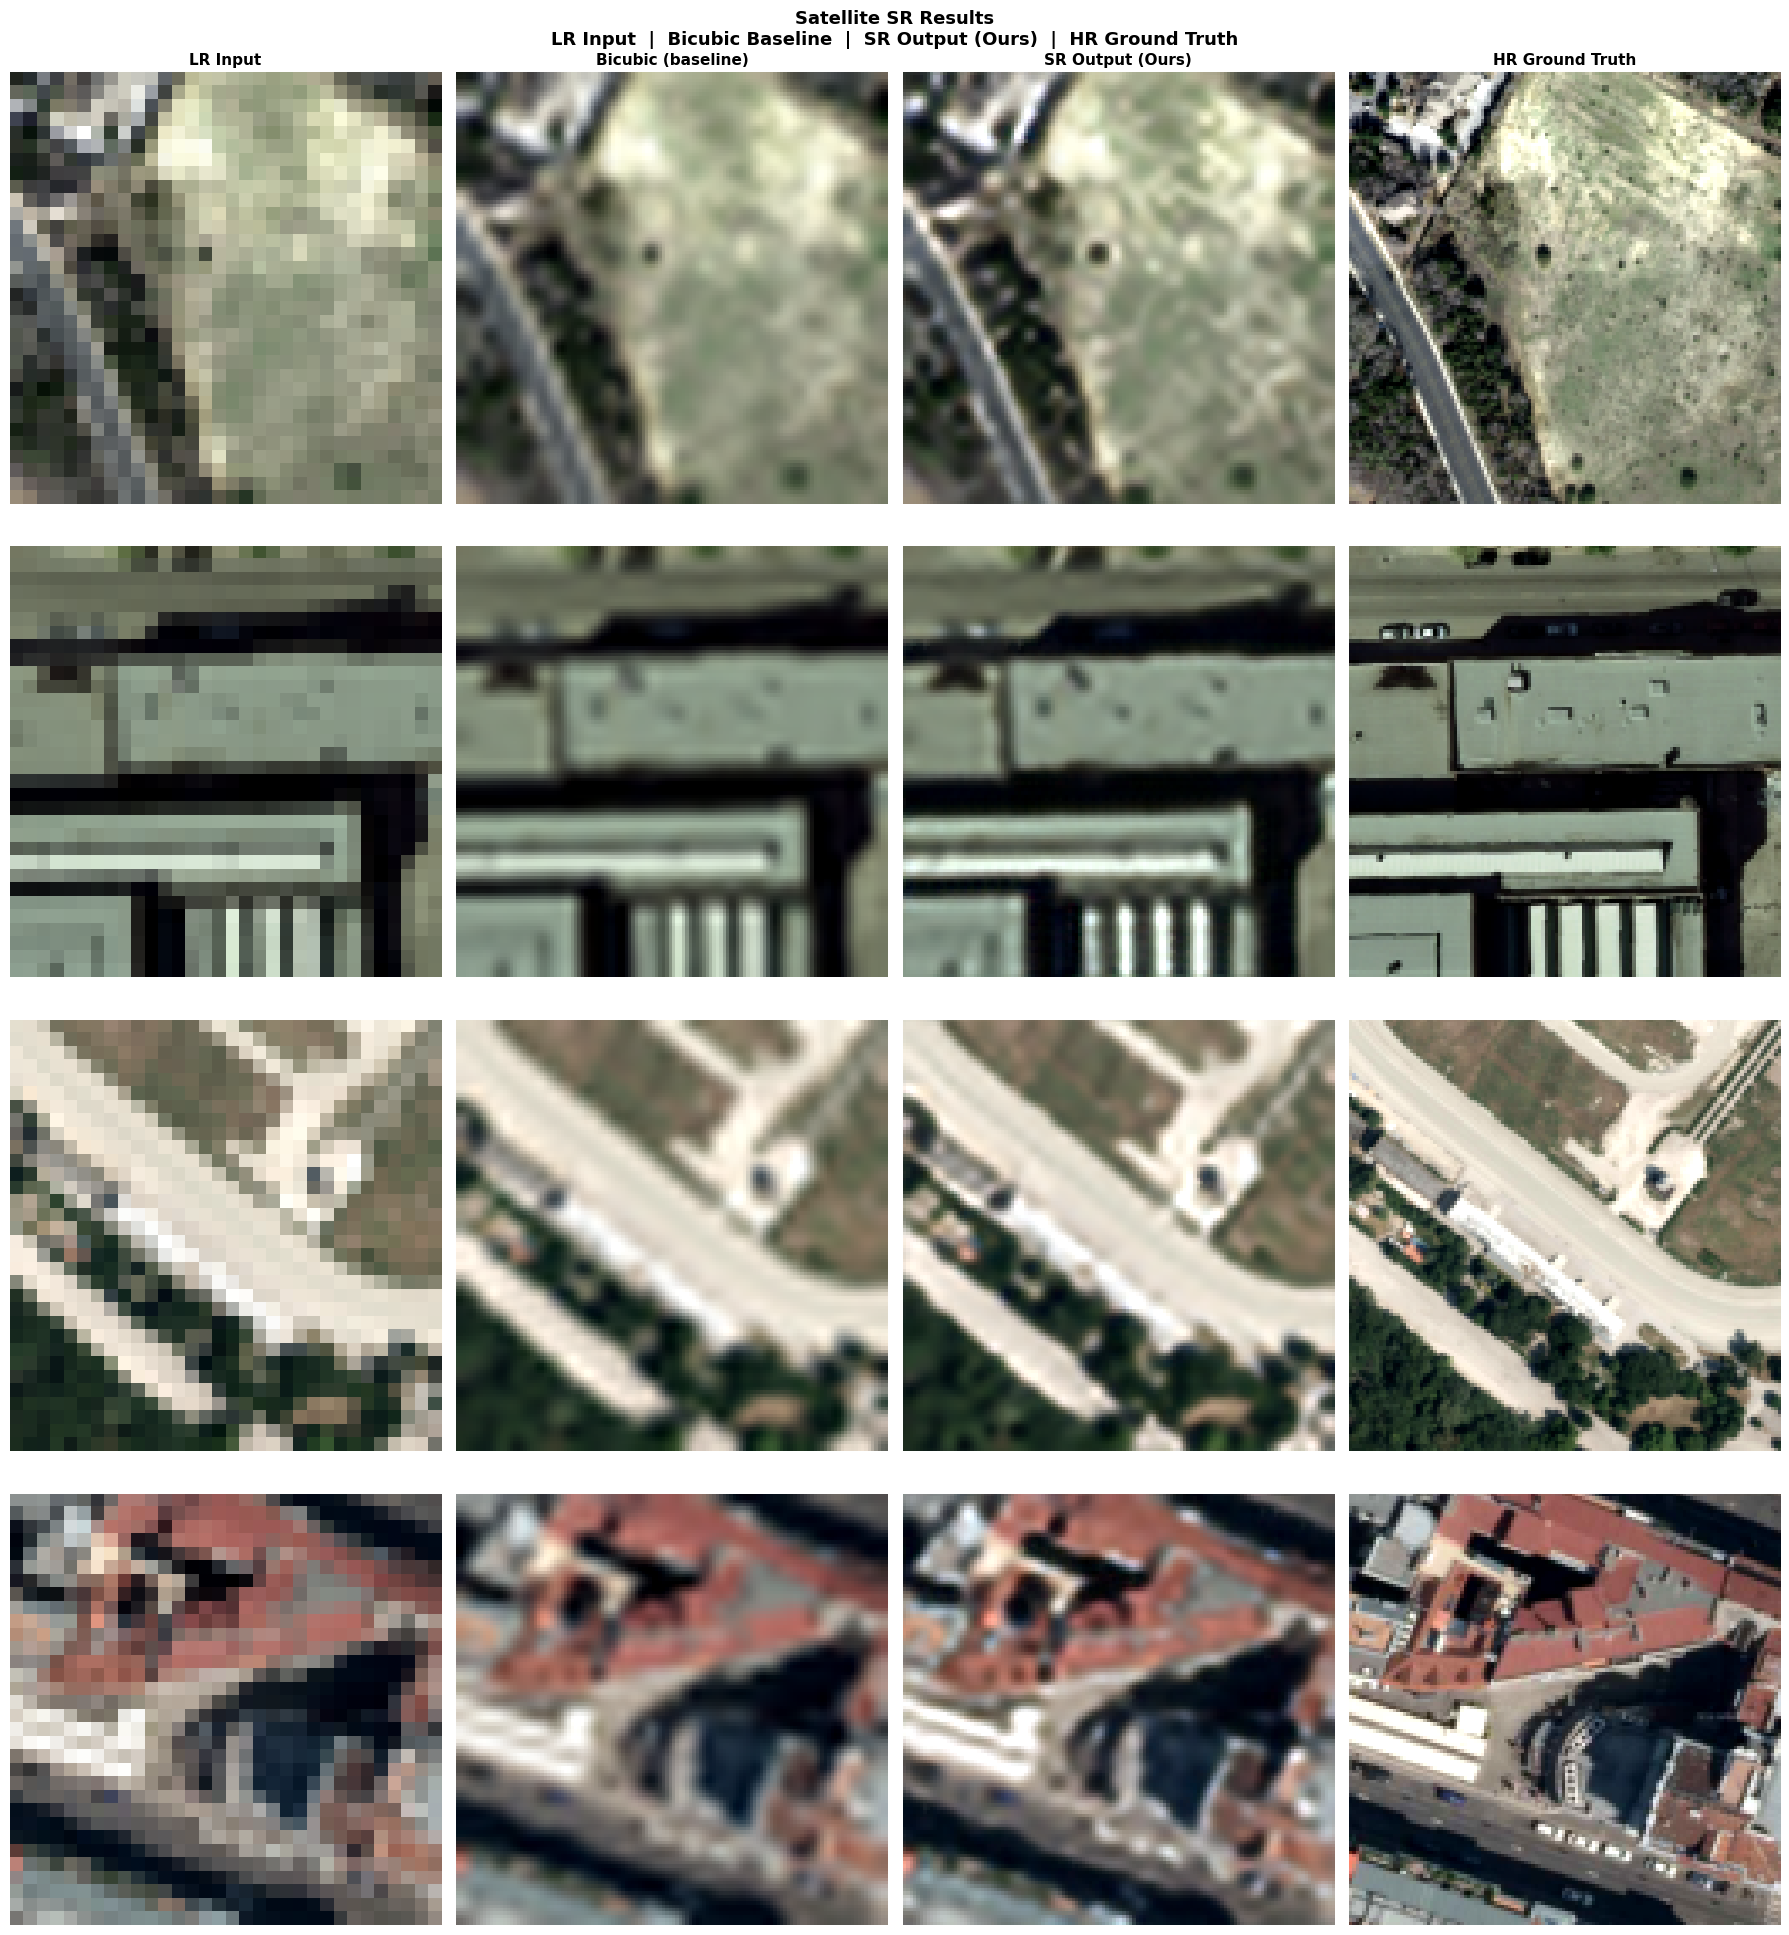

Results saved.

Testing completed successfully!


In [9]:
# ==========================================
# TESTING ON DIV2K + 4x SATELLITE DATASET
# ==========================================

# Load trained model
model.load_state_dict(
    torch.load(
        "/kaggle/input/notebooks/vujjapunithsai/notebookf4890831d9/satellite_sr_model.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Pretrained model loaded successfully!")

# =====================================================
# DIV2K TESTING
# =====================================================

print("\n" + "="*60)
print("TESTING ON DIV2K DATASET")
print("="*60)

div2k_paths = discover_satellite_images(
    "/kaggle/input/datasets/takihasan/div2k-dataset-for-super-resolution"
)

div2k_dataset = SatelliteSRDataset(
    div2k_paths,
    augment=False
)

print(f"DIV2K Images Found: {len(div2k_dataset)}")

visualize_satellite_results(
    model,
    div2k_dataset,
    num_samples=4
)

# =====================================================
# 4x SATELLITE TESTING
# =====================================================

print("\n" + "="*60)
print("TESTING ON 4x SATELLITE DATASET")
print("="*60)

satellite_paths = discover_satellite_images(
    "/kaggle/input/datasets/cristobaltudela/4x-satellite-image-super-resolution"
)

satellite_dataset = SatelliteSRDataset(
    satellite_paths,
    augment=False
)

print(f"Satellite Images Found: {len(satellite_dataset)}")

visualize_satellite_results(
    model,
    satellite_dataset,
    num_samples=4
)

print("\nTesting completed successfully!")

In [ ]:
import os

print(os.listdir("/kaggle/input"))


In [ ]:
print(os.listdir("/kaggle/input/datasets"))

In [ ]:
import os

for root, dirs, files in os.walk('/kaggle/working'):
    for f in files:
        print(f, os.path.getsize(os.path.join(root, f))/1024, "KB")

In [ ]:
import os
import shutil

working_dir = "/kaggle/working"

for item in os.listdir(working_dir):
    item_path = os.path.join(working_dir, item)

    try:
        if os.path.isfile(item_path) or os.path.islink(item_path):
            os.remove(item_path)
        elif os.path.isdir(item_path):
            shutil.rmtree(item_path)

        print(f"Deleted: {item_path}")

    except Exception as e:
        print(f"Failed to delete {item_path}: {e}")

print("kaggle/working cleared.")